#### helper functions

In [1]:
import numpy as np
import copy
from main1 import OnlineSLDSModel
import matplotlib.pyplot as plt
import pandas as pd

def fro_error_relative(X_true, X_est, eps=1e-12):
    """
    Relative Frobenius-style error for any shape:
        ||vec(X_est) - vec(X_true)||_2 / ||vec(X_true)||_2
    """
    X_true_flat = np.ravel(X_true)
    X_est_flat = np.ravel(X_est)
    return np.linalg.norm(X_est_flat - X_true_flat) / (np.linalg.norm(X_true_flat) + eps)


def matrix_error(plant, model, eps=1e-12):
    err_A = fro_error_relative(plant.As, model.As, eps)
    err_B = fro_error_relative(plant.Bs, model.Bs, eps)
    err_C = fro_error_relative(plant.Cs, model.Cs, eps)

    total_err = err_A + err_B + err_C
    avg_err = total_err / 3

    return total_err, avg_err, err_A, err_B, err_C


def make_mismatched_model_from_plant(plant, As_mismatch_level=0.1, Bs_mismatch_level=0.1, Cs_mismatch_level=0.1, zero_bias=True, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)

    model = copy.deepcopy(plant)

    # -------- A --------
    A_true = plant.As.copy()
    A_noise = np.random.randn(*A_true.shape)
    A_noise = A_noise / (np.linalg.norm(A_noise.ravel()) + 1e-12) * (As_mismatch_level * np.linalg.norm(A_true.ravel()))
    A_model = A_true + A_noise
    #A_model = A_true + As_mismatch_level * np.random.randn(*A_true.shape)
    model.As = A_model.copy()
    model.dynamics.As = A_model.copy()

    # -------- B --------
    B_true = plant.Bs.copy()
    B_noise = np.random.randn(*B_true.shape)
    B_noise = B_noise / (np.linalg.norm(B_noise.ravel()) + 1e-12) * (Bs_mismatch_level * np.linalg.norm(B_true.ravel()))
    B_model = B_true + B_noise
    #B_model = B_true + Bs_mismatch_level * np.random.randn(*B_true.shape)
    model.Bs = B_model.copy()

    # -------- C --------
    C_true = plant.Cs.copy()
    C_noise = np.random.randn(*C_true.shape)
    C_noise = C_noise / (np.linalg.norm(C_noise.ravel()) + 1e-12) * (Cs_mismatch_level * np.linalg.norm(C_true.ravel()))
    C_model = C_true + C_noise
    #C_model = C_true + Cs_mismatch_level * np.random.randn(*C_true.shape)
    model.Cs = C_model.copy()
    model.emissions.Cs = C_model.copy()

    # -------- bias --------
    if zero_bias:
        model.dynamics.bs = np.zeros_like(model.dynamics.bs)
        model.bs = np.zeros_like(model.bs)

    return model

c:\Users\jxiao85\AppData\Local\anaconda3\envs\ndac\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
N = 10 # output y dimension
D = 4 # continuous state x dimension
K = 1 # number of discrete regimes
M = 2 # input u dimension
transitions="recurrent_only"
dynamics="gaussian"
emissions="gaussian"

# plant-model mismatch
As_mismatch_level = 0.15 # 15% matrix mismatch
Bs_mismatch_level = 0.15 # 15% matrix mismatch
Cs_mismatch_level = 0.15 # 15% matrix mismatch

## Python test

### Build model, estimator, filters, and u (input)

In [3]:
plant = OnlineSLDSModel(N=N,D=D,K=K,M=M,transitions=transitions,dynamics=dynamics,emissions=emissions,dt=0.01,alpha_variance=0.99,x_variance=1.1,SigmasScaler=2,with_noise=True)

model = make_mismatched_model_from_plant(
    plant,
    As_mismatch_level=As_mismatch_level,
    Bs_mismatch_level=Bs_mismatch_level,
    Cs_mismatch_level=Cs_mismatch_level,
    zero_bias=True,
    random_seed=0
)

total_err, avg_err, err_A, err_B, err_C = matrix_error(plant, model)

print(f"Mismatch level target: A {As_mismatch_level:.3f}, B {Bs_mismatch_level:.3f}, C {Cs_mismatch_level:.3f}")
print(f"Relative A error: {err_A:.4f}")
print(f"Relative B error: {err_B:.4f}")
print(f"Relative C error: {err_C:.4f}")
print(f"Total average error: {avg_err:.4f}")

# estimator
#estimator = copy.deepcopy(model)
estimator_para = copy.deepcopy(model)
estimator_kf = copy.deepcopy(model)

# stimulus and input
fs = 100   
duration = 10
t = np.arange(0, duration, 1/fs)
u_excite = np.sin(2 * np.pi * 0.2 * t)
u_inhibit = np.sin(2 * np.pi * 0.5 * t)
y = np.array([1,4,2,0,1])

Mismatch level target: A 0.150, B 0.150, C 0.150
Relative A error: 0.1500
Relative B error: 0.1500
Relative C error: 0.1500
Total average error: 0.1500


In [4]:
# goal: could replace self._ExPKF_filter(u, y) 
def _para_adapt_filter(self, u, y, Qmu = None, qmu_scale=1e-6):

    # ----------- COMMENT OUT IF IN MAIN1.PY ----------
    # convert to arrays and ensure 2D (1,M) and (1,N)
    u = np.asarray(u)
    y = np.asarray(y)
    if u.ndim == 1:
        u = u[None, :]
    if y.ndim == 1:
        y = y[None, :]
    # ----------------------------------------------

    # append histories
    self.u = np.vstack([self.u, u])         # (t, M)
    self.y = np.vstack([self.y, y])         # (t, N)
    # -> now self.u[-1] is u_t, self.u[-2] is u_{t-1}, ... same for self.y
    
    # set parameters for current regime
    z = int(getattr(self, "zhat", 0))
    A = np.asarray(self.As[z])                  # (D,D)
    B = np.asarray(self.Bs[z])                  # (D,M)
    b = np.asarray(self.bs[z]).reshape(-1)      # (D,)
    C = np.asarray(self.Cs[0])                  # (N,D)
    d = np.asarray(self.ds[0]).reshape(-1)      # (N,)
    Ds = np.asarray(self.Ds[0])                 # (N,M)
    D = A.shape[0]
    N = C.shape[0]
    M = u.shape[1]
    # print(f"A shape: {A.shape}, B shape: {B.shape}, b shape: {b.shape}, C shape: {C.shape}, d shape: {d.shape}, Ds shape: {Ds.shape}")

    Q = np.asarray(getattr(self, "Q", np.eye(D) * 1e-6)) # process noise for x
    R = np.asarray(getattr(self, "E", np.eye(N) * 1.0)) # measurement noise covariance
    if Qmu is None:
        Qmu = np.eye(D) * float(qmu_scale) # smaller qmuscale means slower adaptation (more stable mu)
    else:
        Qmu = np.asarray(Qmu)

    # initialize augmented state xaug and covariance matrix P_aug (if not exist)
    # (if xhat_aug exists, self.xhat_aug stores the previous step's augmented estimates)
    if not hasattr(self, "xhat_aug"):
        x0 = np.asarray(self.xhat[-1]).reshape(-1)      # (D,)
        mu0 = np.zeros(D)                               # (D,)
        self.xhat_aug = np.concatenate([x0, mu0])       # (2D,)

        # initial cov
        Pxx0 = np.asarray(self.P[-1])
        Pmm0 = np.eye(D) * float(qmu_scale)
        self.P_aug = np.block([
            [Pxx0, np.zeros((D, D))],
            [np.zeros((D, D)), Pmm0]
        ])

        # self.muhat_hist = []

    # build augmented matrices
    I = np.eye(D)
    Z = np.zeros((D, D))
    A_aug = np.block([[A, I],
                      [Z, I]])                           # (2D,2D)
    B_aug = np.vstack([B, np.zeros((D, M))])             # (2D,M)
    b_aug = np.concatenate([b, np.zeros(D)])             # (2D,)
    C_aug = np.hstack([C, np.zeros((N, D))])             # (N,2D)
    Q_aug = np.block([[Q, np.zeros((D, D))],
                      [np.zeros((D, D)), Qmu]])          # (2D,2D)

    # predict                 
    u_last = self.u[-2] # u_{t-1}
    x_pred_aug = A_aug @ self.xhat_aug + B_aug @ u_last + b_aug
    P_pred_aug = A_aug @ self.P_aug @ A_aug.T + Q_aug
    y_pred = C_aug @ x_pred_aug + d
    # y_pred = C_aug @ x_pred_aug + Ds @ u_last + d  

    # update
    innov = (self.y[-1] - y_pred)                           # innovation/residual, y_{t} - y_pred_{t},  (N,)
    S = R + C_aug @ P_pred_aug @ C_aug.T                    # innov covariance, (N,N)
    K = P_pred_aug @ C_aug.T @ np.linalg.inv(S)             # kalman gain, (2D,N)
    xhat_aug = x_pred_aug + K @ innov
    P_aug = (np.eye(2 * D) - K @ C_aug) @ P_pred_aug
    yhat = C_aug @ xhat_aug + d
    # yhat = C_aug @ x_pred_aug + Ds @ u_last + d

    # unpack
    xhat = xhat_aug[:D] # first half is xhat
    muhat = xhat_aug[D:] # second half is muhat
    self.xhat_aug = xhat_aug
    self.P_aug = P_aug
    self.muhat = muhat
    # self.muhat_hist.append(muhat.copy())

    # only saving non-augmented xhat and P history for the downstream workflow
    self.x_pred = np.vstack([self.x_pred, x_pred_aug[:D][None, :]])
    self.xhat = np.vstack([self.xhat, xhat[None, :]])
    P_pred_xx = P_pred_aug[:D, :D] # only keep x cov pred
    P_xx = P_aug[:D, :D] # only keep x cov
    self.P_pred = np.concatenate([self.P_pred, P_pred_xx[None, :, :]], axis=0)
    self.P = np.concatenate([self.P, P_xx[None, :, :]], axis=0)
    self.P_inv = np.linalg.inv(P_xx)

    # ----------- COMMENT OUT IF IN MAIN1.PY ----------
    return xhat, muhat, yhat # commented out if in main1.py
    # -----------------------------------------------------

In [5]:
# goal: replace parameter-adaptive KF with regular KF (no mu)
def _kf_filter(self, u, y):
    # ----------- COMMENT OUT IF IN MAIN1.PY ----------
    # convert to arrays and ensure 2D (1,M) and (1,N)
    u = np.asarray(u)
    y = np.asarray(y)
    if u.ndim == 1:
        u = u[None, :]
    if y.ndim == 1:
        y = y[None, :]
    # ----------------------------------------------

    # append histories
    self.u = np.vstack([self.u, u])   # (t, M)
    self.y = np.vstack([self.y, y])   # (t, N)
    # -> now self.u[-1] is u_t, self.u[-2] is u_{t-1}, ... same for self.y

    # set parameters for current regime
    z = int(getattr(self, "zhat", 0))
    A = np.asarray(self.As[z])                  # (D,D)
    B = np.asarray(self.Bs[z])                  # (D,M)
    b = np.asarray(self.bs[z]).reshape(-1)      # (D,)
    C = np.asarray(self.Cs[0])                  # (N,D)
    d = np.asarray(self.ds[0]).reshape(-1)      # (N,)
    Ds = np.asarray(self.Ds[0])                 # (N,M)  (kept for consistency)
    D = A.shape[0]
    N = C.shape[0]

    Q = np.asarray(getattr(self, "Q", np.eye(D) * 1e-6))  # process noise for x
    R = np.asarray(getattr(self, "E", np.eye(N) * 1.0))   # measurement noise covariance

    # predict
    u_last = self.u[-2]  # u_{t-1}
    x_prev = np.asarray(self.xhat[-1]).reshape(-1)        # (D,)
    P_prev = np.asarray(self.P[-1])                       # (D,D)

    x_pred = A @ x_prev + B @ u_last + b                  # (D,)
    P_pred = A @ P_prev @ A.T + Q                         # (D,D)

    # measurement prediction
    y_pred = C @ x_pred + d                               # (N,)

    # update
    innov = (self.y[-1] - y_pred)                         # (N,)
    S = R + C @ P_pred @ C.T                              # (N,N)
    K = P_pred @ C.T @ np.linalg.inv(S)                   # (D,N)

    xhat = x_pred + K @ innov                             # (D,)
    P = (np.eye(D) - K @ C) @ P_pred                      # (D,D)

    yhat = C @ xhat + d                                   # (N,)

    # save for downstream workflow
    self.x_pred = np.vstack([self.x_pred, x_pred[None, :]])
    self.xhat   = np.vstack([self.xhat,   xhat[None, :]])
    self.P_pred = np.concatenate([self.P_pred, P_pred[None, :, :]], axis=0)
    self.P      = np.concatenate([self.P,      P[None, :, :]], axis=0)
    self.P_inv  = np.linalg.inv(P)

    return xhat, yhat

### Apply filters

In [6]:
TrueXs = []
EstXs = [] # this is the parameter-adaptive KF estimate
EstXs_kf = [] # this is the regular KF estimate (no mu)
TrueZs = []
EstZs = []
Observations = []
MuHats = []

for t in range(u_excite.shape[0]):
    u_t = np.array([u_excite[t], u_inhibit[t]])  # (2,)

    # sample SLDS
    _ = plant.sample(u_t)  # we changed the main1.py sample() to try returning bs so that we could plot it; doesn't really matter
    TrueX = plant.x
    Observation = plant.y
    TrueZ = plant.z

    # filter: parameter-adaptive KF or regular KF (no mu)
    xhat, muhat, yhat = _para_adapt_filter(estimator_para, u_t, Observation, qmu_scale=1e-6)
    xhat_kf, yhat_kf = _kf_filter(estimator_kf, u_t, Observation)

    EstX = xhat
    EstX_kf = xhat_kf
    EstZ = 0 # hard coded for now

    # --- store results ---
    TrueXs.append(TrueX)
    EstXs.append(EstX)
    EstXs_kf.append(EstX_kf)
    TrueZs.append(TrueZ)
    EstZs.append(EstZ)
    Observations.append(Observation)
    MuHats.append(muhat) 

In [7]:
# print(len(TrueXs))
# print(TrueXs[0].shape)
T = len(TrueXs)
TrueXs = np.array(TrueXs) # (T, 2)
EstXs  = np.array(EstXs)
EstXs_kf = np.array(EstXs_kf)
TrueZs = np.array(TrueZs) # (T,)
EstZs  = np.array(EstZs)
Observations = np.array(Observations) # (T,)
MuHats = np.array(MuHats) # (T, D)
U = np.stack([u_excite, u_inhibit], axis=1) # (T, 2)

### Example result

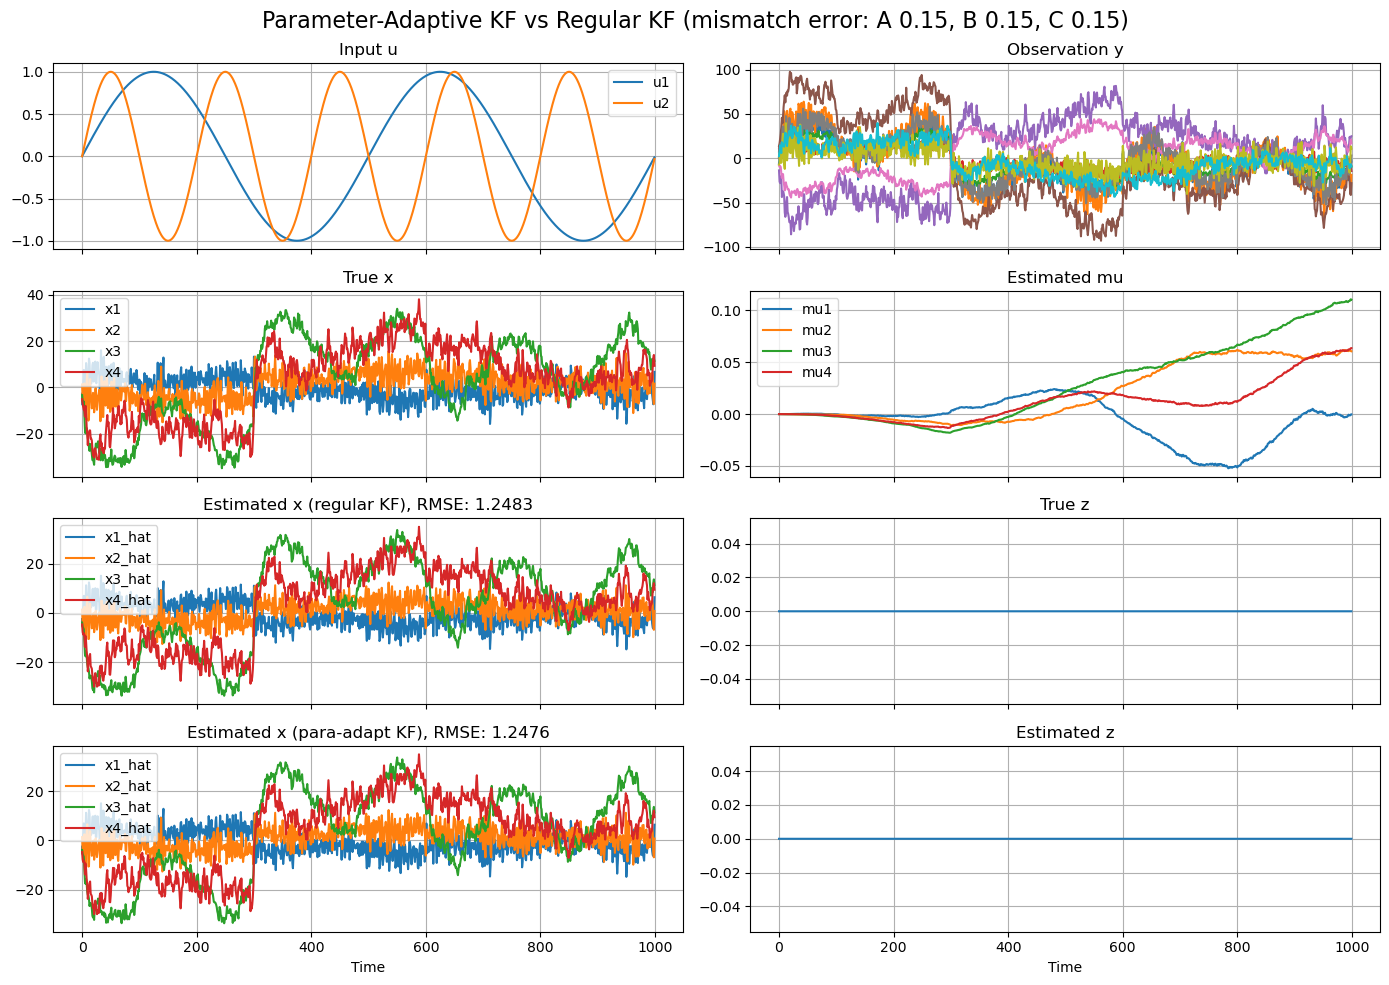

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

# input (2D)
Du = U.shape[1]
for d in range(Du):
    axes[0, 0].plot(U[:, d], label=f"u{d+1}")
axes[0, 0].set_title("Input u")
axes[0, 0].legend()

# observation
axes[0, 1].plot(Observations)
axes[0, 1].set_title("Observation y")

# True x (2D)
Dx = TrueXs.shape[1]
for d in range(Dx):
    axes[1, 0].plot(TrueXs[:, d], label=f"x{d+1}")
axes[1, 0].set_title("True x")
axes[1, 0].legend()

# Estimated x (2D)
for d in range(Dx):
    axes[2, 0].plot(EstXs_kf[:, d], label=f"x{d+1}_hat")
axes[2, 0].set_title(f"Estimated x (regular KF), RMSE: {np.sqrt(np.mean((EstXs_kf - TrueXs)**2)):.4f}")
axes[2, 0].legend()

# Estimated x (2D)
for d in range(Dx):
    axes[3, 0].plot(EstXs[:, d], label=f"x{d+1}_hat")
axes[3, 0].set_title(f"Estimated x (para-adapt KF), RMSE: {np.sqrt(np.mean((EstXs - TrueXs)**2)):.4f}")
axes[3, 0].legend()

# Estimated mu
Dmu = MuHats.shape[1]
for d in range(Dmu):
    axes[1, 1].plot(MuHats[:, d], label=f"mu{d+1}")
axes[1, 1].set_title("Estimated mu")
axes[1, 1].legend()

# True z
axes[2, 1].step(range(T), TrueZs, where="post")
axes[2, 1].set_title("True z")

# Estimated z
axes[3, 1].step(range(T), EstZs, where="post")
axes[3, 1].set_title("Estimated z")

for ax in axes.flat:
    ax.grid(True)
axes[3, 0].set_xlabel("Time")
axes[3, 1].set_xlabel("Time")

plt.suptitle("Parameter-Adaptive KF vs Regular KF (mismatch error: A {:.2f}, B {:.2f}, C {:.2f})".format(As_mismatch_level, Bs_mismatch_level, Cs_mismatch_level), fontsize=16)
plt.tight_layout()
plt.show()


### Mismatch level sweep

##### helper functions

In [12]:
# ---------- metrics ----------
def rmse(true_x, est_x):
    true_x = np.asarray(true_x)
    est_x = np.asarray(est_x)
    return np.sqrt(np.mean((est_x - true_x) ** 2))

def per_dim_rmse(true_x, est_x):
    true_x = np.asarray(true_x)
    est_x = np.asarray(est_x)
    return np.sqrt(np.mean((est_x - true_x) ** 2, axis=0))

def overall_r2(true_x, est_x, eps=1e-12):
    true_x = np.asarray(true_x)
    est_x = np.asarray(est_x)
    ss_res = np.sum((true_x - est_x) ** 2)
    ss_tot = np.sum((true_x - np.mean(true_x, axis=0, keepdims=True)) ** 2)
    return 1 - ss_res / (ss_tot + eps)

def run_one_sweep_condition(base_plant, mismatch_level, seed_model=0, seed_rollout=0, qmu_scale=1e-6):
    # fresh plant for this condition
    plant_run = copy.deepcopy(base_plant)

    # mismatched model + estimator
    model_run = make_mismatched_model_from_plant(
        plant_run,
        As_mismatch_level=mismatch_level,
        Bs_mismatch_level=mismatch_level,
        Cs_mismatch_level=mismatch_level,
        zero_bias=True,
        random_seed=seed_model
    )
    #estimator_run = copy.deepcopy(model_run)
    estimator_run_para = copy.deepcopy(model_run)
    estimator_run_kf = copy.deepcopy(model_run)

    total_err, avg_err, err_A, err_B, err_C = matrix_error(plant_run, model_run)

    np.random.seed(seed_rollout)

    TrueXs = []
    EstXs = []
    EstXs_kf = []
    TrueZs = []
    EstZs = []
    Observations = []
    MuHats = []

    for tt in range(u_excite.shape[0]):
        u_t = np.array([u_excite[tt], u_inhibit[tt]])

        # plant step
        _ = plant_run.sample(u_t) # output is bs - doesn't matter
        TrueX = np.asarray(plant_run.x).copy()
        Observation = np.asarray(plant_run.y).copy()
        TrueZ = plant_run.z

        #xhat, muhat, yhat = _para_adapt_filter(estimator_run, u_t, Observation, qmu_scale=qmu_scale)
        #xhat_kf, yhat_kf = _kf_filter(estimator_run, u_t, Observation)
        xhat, muhat, yhat = _para_adapt_filter(estimator_run_para, u_t, Observation, qmu_scale=qmu_scale)
        xhat_kf, yhat_kf = _kf_filter(estimator_run_kf, u_t, Observation)

        TrueXs.append(TrueX)
        EstXs.append(np.asarray(xhat).copy())
        EstXs_kf.append(np.asarray(xhat_kf).copy())
        TrueZs.append(TrueZ)
        EstZs.append(0)
        Observations.append(Observation)
        MuHats.append(np.asarray(muhat).copy())

    TrueXs = np.array(TrueXs)
    EstXs = np.array(EstXs)
    EstXs_kf = np.array(EstXs_kf)
    TrueZs = np.array(TrueZs)
    EstZs = np.array(EstZs)
    Observations = np.array(Observations)
    MuHats = np.array(MuHats)

    return {
        "mismatch_level": mismatch_level,
        "matrix_error_total": total_err,
        "matrix_error_avg": avg_err,
        "matrix_error_A": err_A,
        "matrix_error_B": err_B,
        "matrix_error_C": err_C,
        "rmse_para": rmse(TrueXs, EstXs),
        "rmse_kf": rmse(TrueXs, EstXs_kf),
        "r2_para": overall_r2(TrueXs, EstXs),
        "r2_kf": overall_r2(TrueXs, EstXs_kf),
        "rmse_dim_para": per_dim_rmse(TrueXs, EstXs),
        "rmse_dim_kf": per_dim_rmse(TrueXs, EstXs_kf),
        "TrueXs": TrueXs,
        "EstXs": EstXs,
        "EstXs_kf": EstXs_kf,
        "TrueZs": TrueZs,
        "EstZs": EstZs,
        "Observations": Observations,
        "MuHats": MuHats,
    }



##### run mismatch level sweep

In [13]:
mismatch_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
n_repeats = 5
qmu_scale = 1e-6

# use a fixed base plant
base_plant = copy.deepcopy(plant)

rows = []
all_results = {}

for m in mismatch_levels:
    all_results[m] = []
    for rep in range(n_repeats):
        res = run_one_sweep_condition(
            base_plant=base_plant,
            mismatch_level=m,
            seed_model=rep,
            seed_rollout=rep,
            qmu_scale=qmu_scale
        )
        all_results[m].append(res)

        rows.append({
            "mismatch_level": m,
            "repeat": rep,
            "matrix_error_avg": res["matrix_error_avg"],
            "matrix_error_A": res["matrix_error_A"],
            "matrix_error_B": res["matrix_error_B"],
            "matrix_error_C": res["matrix_error_C"],
            "rmse_para": res["rmse_para"],
            "rmse_kf": res["rmse_kf"],
            "r2_para": res["r2_para"],
            "r2_kf": res["r2_kf"],
        })

df_results = pd.DataFrame(rows)
df_summary = (
    df_results.groupby("mismatch_level", as_index=False)
    .agg(
        matrix_error_avg_mean=("matrix_error_avg", "mean"),
        matrix_error_avg_std=("matrix_error_avg", "std"),
        rmse_para_mean=("rmse_para", "mean"),
        rmse_para_std=("rmse_para", "std"),
        rmse_kf_mean=("rmse_kf", "mean"),
        rmse_kf_std=("rmse_kf", "std"),
        r2_para_mean=("r2_para", "mean"),
        r2_para_std=("r2_para", "std"),
        r2_kf_mean=("r2_kf", "mean"),
        r2_kf_std=("r2_kf", "std"),
    )
)

display(df_summary)

,mismatch_level,matrix_error_avg_mean,matrix_error_avg_std,rmse_para_mean,rmse_para_std,rmse_kf_mean,rmse_kf_std,r2_para_mean,r2_para_std,r2_kf_mean,r2_kf_std
0,0.00,0.00,0.000000e+00,0.620387,0.010706,0.629785,0.010480,0.992003,0.000294,0.991759,0.000290
1,0.05,0.05,1.601806e-15,0.728717,0.070858,0.735956,0.071893,0.988922,0.001971,0.988702,0.002019
2,0.10,0.10,3.188314e-15,0.908011,0.123662,0.912833,0.121575,0.982665,0.004353,0.982495,0.004303
3,0.20,0.20,6.356663e-15,1.456957,0.142002,1.457455,0.135815,0.955474,0.009140,0.955478,0.008783
4,0.30,0.30,9.537625e-15,2.122912,0.162607,2.120396,0.162383,0.905691,0.015478,0.905921,0.015372
5,0.50,0.50,1.593987e-14,3.145763,0.183956,3.142766,0.186257,0.793558,0.026712,0.793946,0.026873
6,0.80,0.80,2.545457e-14,4.259531,0.659799,4.257624,0.662405,0.616001,0.126105,0.616298,0.126555
7,1.00,1.00,3.184086e-14,4.888235,0.987872,4.887935,0.987336,0.488128,0.215412,0.488224,0.215226


### Sweep result

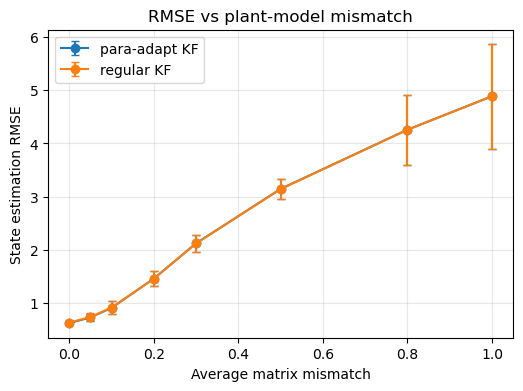

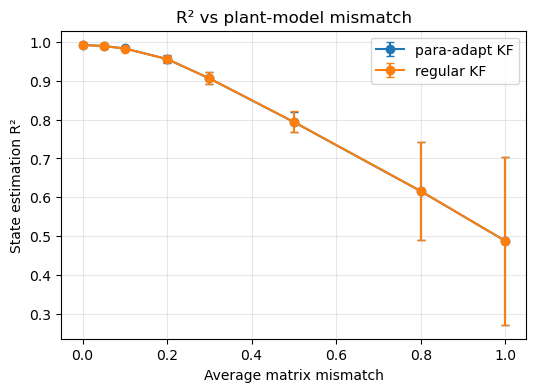

In [14]:
# ---------- mismatch sweep plots ----------
x = df_summary["matrix_error_avg_mean"].values

plt.figure(figsize=(6, 4))
plt.errorbar(
    x, df_summary["rmse_para_mean"], yerr=df_summary["rmse_para_std"],
    marker="o", capsize=3, label="para-adapt KF"
)
plt.errorbar(
    x, df_summary["rmse_kf_mean"], yerr=df_summary["rmse_kf_std"],
    marker="o", capsize=3, label="regular KF"
)
plt.xlabel("Average matrix mismatch")
plt.ylabel("State estimation RMSE")
plt.title("RMSE vs plant-model mismatch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.errorbar(
    x, df_summary["r2_para_mean"], yerr=df_summary["r2_para_std"],
    marker="o", capsize=3, label="para-adapt KF"
)
plt.errorbar(
    x, df_summary["r2_kf_mean"], yerr=df_summary["r2_kf_std"],
    marker="o", capsize=3, label="regular KF"
)
plt.xlabel("Average matrix mismatch")
plt.ylabel("State estimation R²")
plt.title("R² vs plant-model mismatch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()